# Linear model selection and model regularization
----
선형모형을 다시 돌아보자.

$$ Y = \beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p + \epsilon $$

선형모형은 간단함에도 불구하고, interpretablity가 좋고, 종종 좋은 predictive performance를 보인다.

이 장에서는 선형모형의 기본적인 장점은 유지하면서 단점을 보완하는 대안들을 살펴본다.

### Why consider alternatives?

* Prediction accuracy : $p > n$이면 최소제곱 회귀계수가 유일하게 결정되지 않을 수 있다. 또한 설명변수가 많으면 과적합이 발생하기 쉽다. 추정될 모수의 수를 제한하여 추정량의 분산을 줄이고 예측 정확성을 높인다. 설명변수가 많거나 서로 강하게 상관되어 있으면 최소제곱 추정량의 변동성이 커질 수 있는데, 정규화는 약간의 bias를 허용하는 대신 추정량의 분산을 줄일 수 있다.

* Model interpretability : 불필요한 feature 변수를 제외하여 모형을 보다 해석 가능하도록 만든다. feature selection 혹은 variable selection이 자동으로 이루어지는 방법에 대해 알아본다.

### 세가지 방법

* Subset selection : $p$개의 predictor 중에서 반응변수와 연관이 있을 것으로 생각되는 부분 집합을 식별하는 방법.

* Shrinkage (regularization) : $p$개의 predictor를 모형 적합에 사용하지만, 그 중의 일부 predictor들의 해당되는 계수는 0 혹은 0과 매우 가까운 값으로 추정된다. 

* Dimension reduction : $p$개의 predictor를 $M$-dimensional subspace로 투영하는 방법.

## Subset selection

$p$개의 predictor가 있을 때, $k=1, 2, \cdots, p$에 대하여 다음을 실행한다.

* 각 $k$에 대하여 정확히 $\binom{p}{k}$개의 가능한 모형이 있다. 이 모형들에 대해 모두 적합을 진행한다.

  * 각 $k$에 대하여 적합된 모형 중 가장 적합이 잘된 모형이 있을 것이다. 이를 $\mathcal M_k$라 하자.
  
  * 한편 predictor가 없는 단순한 평균 모형은 $\mathcal M_0$라고 하겠다.
  
* $\mathcal M_0, \mathcal M_1, \cdots, \mathcal M_p$ 중에서 best인 모형을 찾는다. 

  * Best를 찾기 위해서 cross-validated prediction error, $C_p$ (AIC), BIC 혹은 adjusted $R^2$ 등이 이용될 수 있다.

## Shrinkage methods

적절한 constraint 혹은 regularization 방법을 통해 불필요한 추정치를 0으로 가깝게 만드는 방법이다.

### Ridge regression

Least square 방식을 다시 돌아보자. 이 방법에서는 다음을 최소화하는 다음을 최소화하는 $\beta$들의 값을 찾는다.

$$ \mathrm{RSS} = \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 $$

반면 ridge regression에서는 다음을 최소화하는 $\beta$들의 값을 찾는다.

$$ \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 + \lambda \sum_{j=1}^{p} \beta_j^2 = \mathrm{RSS} + \lambda \sum_{j=1}^{p} \beta_j^2 $$

- 여기서 $\lambda \geq 0 $으로 tuning parameter라고 불리운다.

절편에는 일반적으로 penalty를 적용하지 않는다.

위 식에서 $\beta$들의  추정량을 $\hat \beta^{R}$이라 하겠다.

$\lambda \sum_{j=1}^{p} \beta_j^2$는 shrinkage penalty라고 불리우며, $\beta$들이 0에 가까울수록 작아진다.

적절한 $\lambda$를 선택하는 것이 중요하며 이는 cross-validation 방법을 통해 선택할 수 있다.

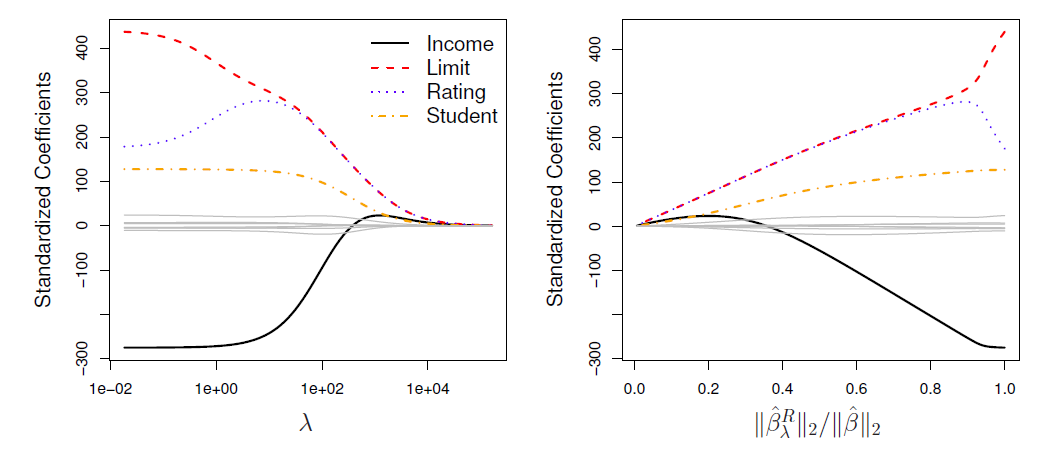

위 그림의 왼쪽에서 보듯 $\lambda$가 커지면 결국 모든 $\beta$들의 추정치는 0에 가까워진다.

오른쪽 그림에서는 x-축에 $ \dfrac{|| \hat \beta_\lambda^R ||_2}{|| \hat \beta ||_2} $를 표현하였다.

여기서 $|| \cdot ||_2$는 $\ell_2$-norm으로서 다음으로 정의한다.

$$ || \beta ||_2 = \sqrt{\sum_{j=1}^{p} \beta_j^2} $$

한편, ridge regression에서는 predictor들을 **표준화**하여 모형을 적합하는 것이 좋다.


$$ \tilde x_{ij} = \frac{x_{ij} - \bar x_j}{s_j} $$

여기서 $s_j$는 $j$번째 변수의 표준편차이다.

- 변수마다 측정 단위가 다르면 penalty가 공정하게 적용되지 않을 수 있다. 따라서 Ridge와 Lasso를 적용하기 전에 설명변수를 표준화하는 것이 일반적이다.

### Bias-variance tradeoff

50개의 데이터와 45개의 predictor를 이용한 시뮬레이션 실험. 실험에서는 모두 non-zero coefficient를 가정하였다.

아래 그림에서 검은 선이 squared bias, 초록색이 variance, test error가 자주색이다.

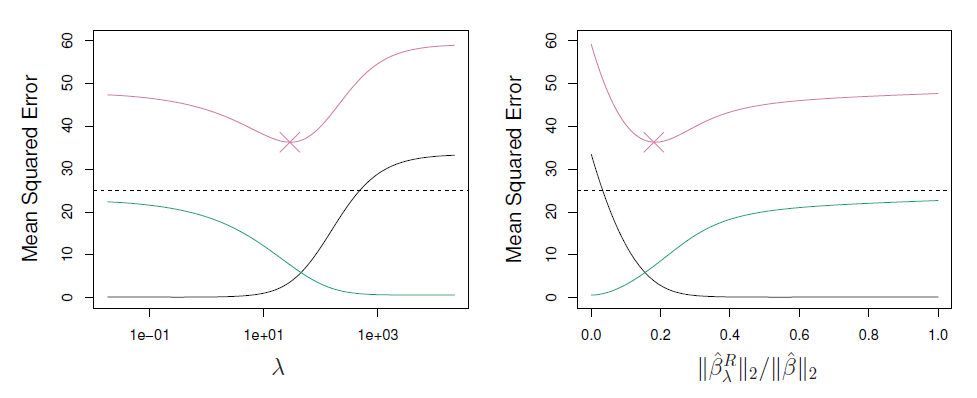

## Lasso 

Ridge regression은 $\lambda$에 따라 coefficient들의 값을 0에 가깝게 보내기는 하지만 완전히 0이 되는 것이 아니기 때문에 최종 모형에는 결국 총 $p$개의 predictor들이 모두 포함된다.

Lasso는 ridge의 대안으로, 다음을 최소화하는 $\beta$들을 찾으며 이를 $\hat \beta_\lambda^L$이라고 하겠다.

$$ \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 + \lambda \sum_{j=1}^{p} |\beta_j| = \mathrm{RSS} + \lambda \sum_{j=1}^{p} |\beta_j| $$

통계적 용어로 이야기하자면, lasso는 $\ell_1$ penalty를 사용하고 ridge는 $\ell_2$ penaltiy를 사용하는 것이다.

Ridge와 마찬가지로 lasso 또한 coefficient 추정치를 0으로 보내지만 ridge와 달리 $\lambda$가 충분히 크면 완전히 0의 값이 된다.

따라서 lasso는 일종의 variable selection 역할을 한다.

Lasso는 sparse 모형을 만들어낸다고도 한다.

마찬가지로 적절한 $\lambda$의 값을 선택하는 것이 중요하며 cross-validation 방법이 이용된다.

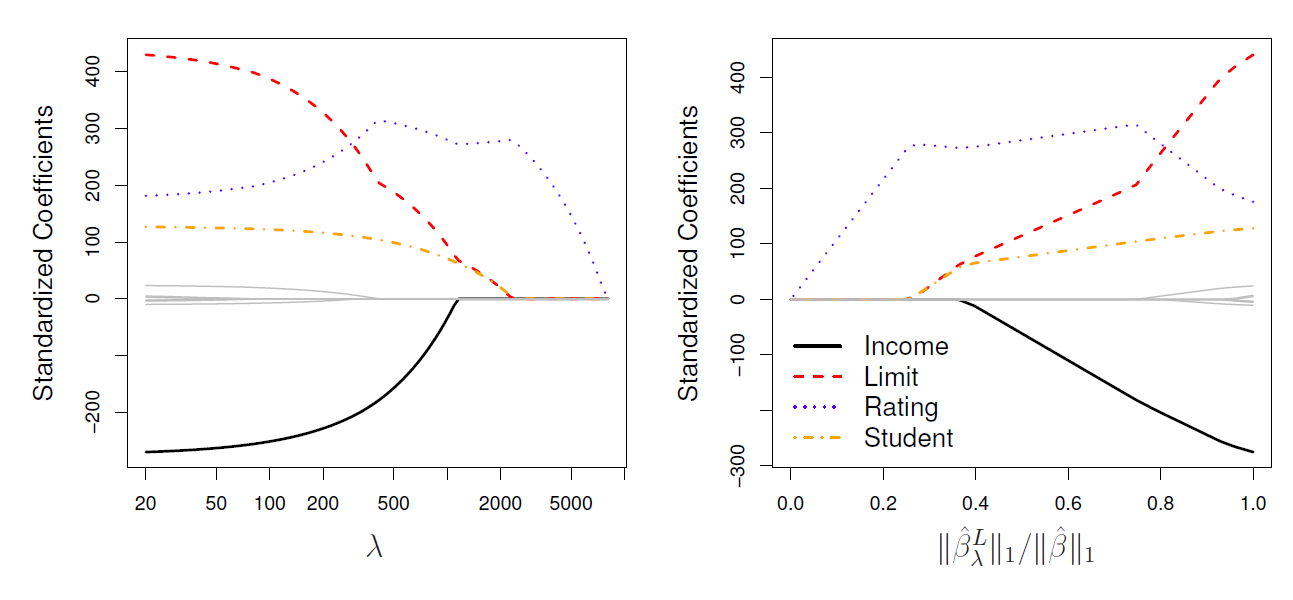

정규화 강도가 커질수록 회귀계수의 절댓값이 작아진다. Lasso에서는 (Ridge와 달리) 일부 계수가 정확히 0이 될 수 있다.

### Ridge와 Lasso의 차이

Lasso와 ridge regression은 각각 결국 다음의 문제를 해결하는 것과 같다.

$$ \arg \min_{\beta} \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2  \text{ subject to }  \sum_{j=1}^{p} |\beta_j| \leq s $$

$$ \arg \min_{\beta} \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2  \text{ subject to }  \sum_{j=1}^{p} \beta_j^2 \leq s $$

그림으로 표현하자면 다음과 같으며, 단순히 Ridge와 Lasso 중 어느 것이 더 낫다고 결론을 지을 수는 없다.

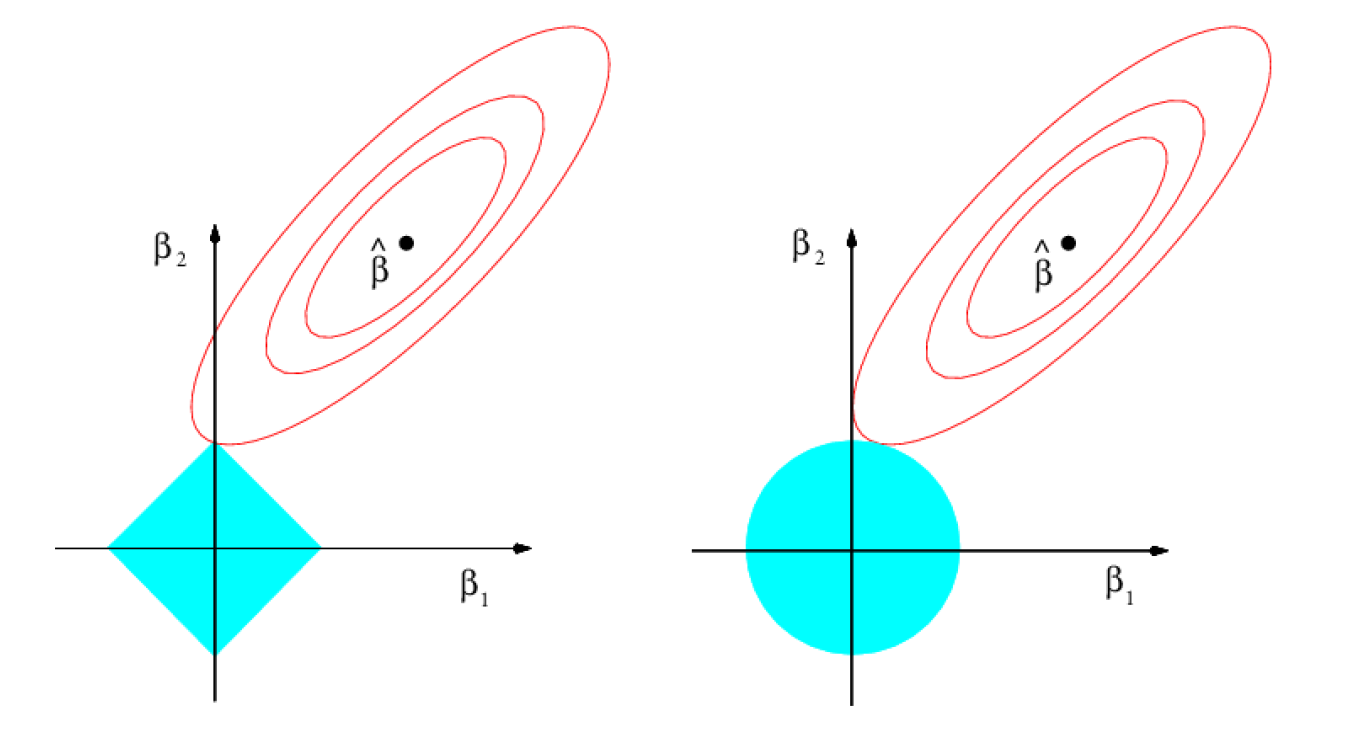

### 모형 선택

앞서 이야기했듯이 $\lambda$는 cross-validation 방법을 통해 정하는 것이 바람직하다.

아래는 먼저 다양한 $\lambda$에 대해 ridge regression을 적합하고, 테스트 자료에서의 MSE를 계산하여 계수와 오차가 $\lambda$에 따라 어떻게 변하는지 살펴보는 예제이다.

(주의: 아래 방법은 alpha 선택을 위해 테스트 자료를 직접 사용한 것으로, cross-validation이 아니며 실제 모형 선택에는 바람직하지 않다. alpha는 이후에 나오는 것처럼 훈련 자료에 대한 cross-validation으로 선택하고, 테스트 자료는 선택된 모형의 최종 성능 평가에만 사용해야 한다.)

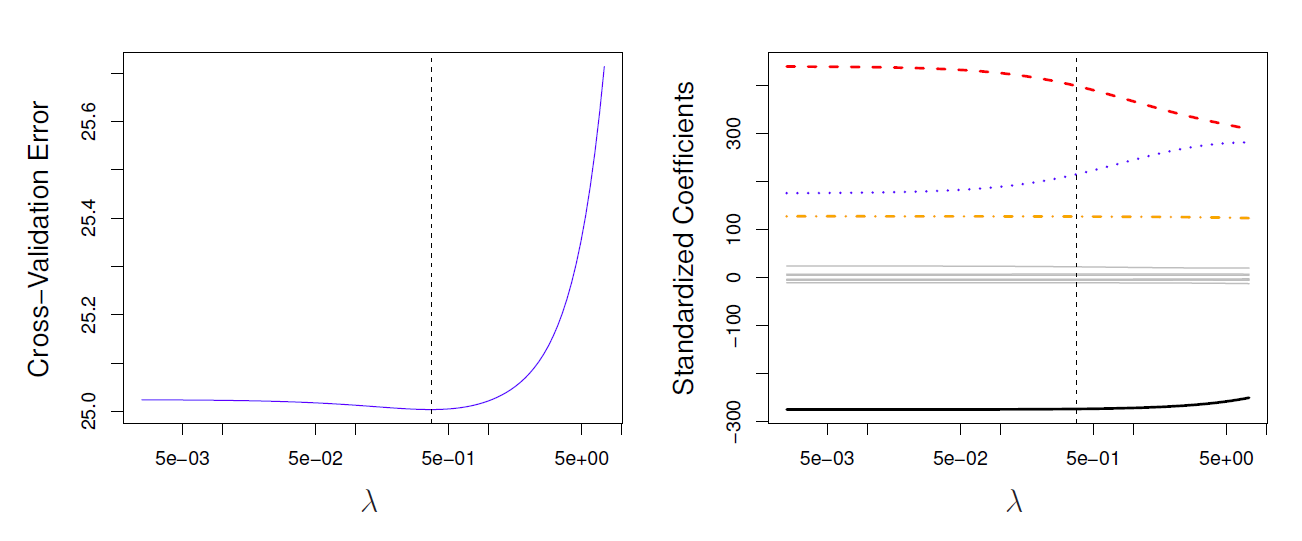

아래는 lasso에 대해서도 마찬가지로, 다양한 $\lambda$에 대해 계수와 테스트 자료에서의 MSE가 어떻게 변하는지 살펴보는 예제이다.

(역시 cross-validation이 아니라 테스트 자료를 이용한 것이므로, 실제 alpha 선택에는 사용하지 않는 것이 좋다.)

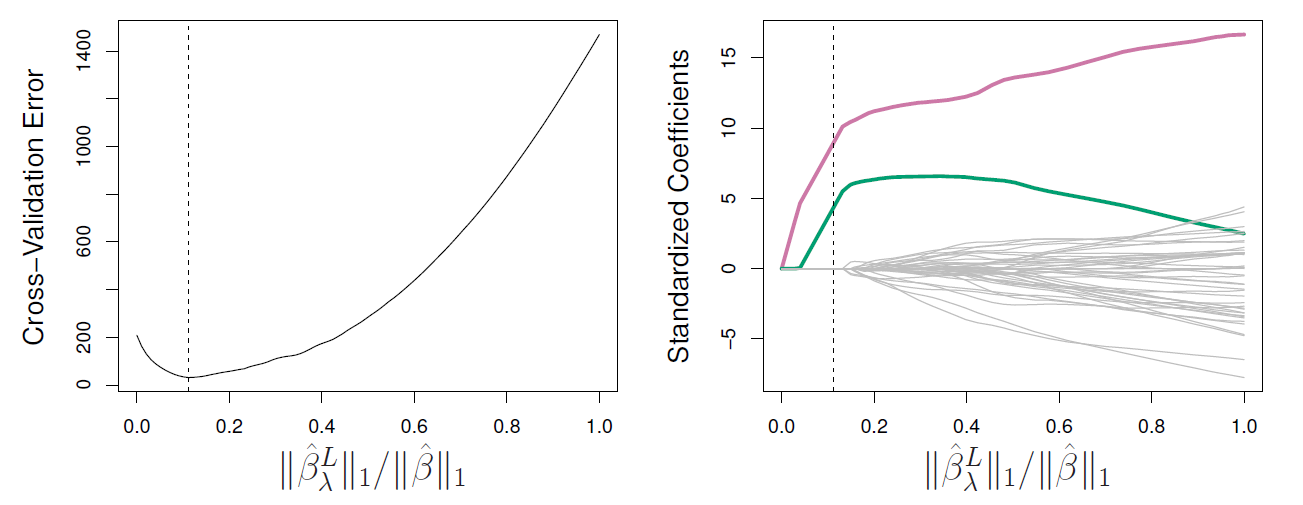

## 엘라스틱넷 (elastic net)

Ridge와 Lasso를 절충한 모델.

그 목적함수는 다음과 같다:

$$
\sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 
+ \lambda \left( r \sum_{j=1}^{p} |\beta_j| + \frac{1 - r}{2} \sum_{j=1}^{p} \beta_j^2 \right)
$$

여기서,

* $\lambda$는 **전체 정규화 강도**를 조절하는 하이퍼파라미터이고,
* $r \in [0, 1]$은 **Lasso와 Ridge 사이의 혼합 비율**이다.

  * $r = 1$이면 Lasso,
  * $r = 0$이면 Ridge,
  * $0 < r < 1$이면 두 기법을 혼합한 형태가 된다.


## Hitter example

여러 지표를 바탕으로 야구(타자) 선수의 연봉을 예측하는 문제.

이 자료는 통산 기록(`CAtBat`, `CHits`, `CRuns`, `CRBI`, `CWalks` 등)과 최근 시즌 기록이 서로 강하게 상관되어 있어, Ridge와 Lasso 같은 정규화 기법이 특히 유용한 대표적인 예로 자주 사용된다.

여기서는 예제를 단순화하기 위해 범주형 변수를 제외한다. 실제 분석에서는 one-hot encoding을 적용하여 포함할 수 있다.

In [1]:
import pandas as pd
df = pd.read_csv('https://gist.githubusercontent.com/keeganhines/59974f1ebef97bbaa44fb19143f90bad/raw/d9bcf657f97201394a59fffd801c44347eb7e28d/Hitters.csv')
df = df.dropna(axis=0)
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N
5,-Alfredo Griffin,594,169,4,74,51,35,11,4408,1133,...,501,336,194,A,W,282,421,25,750.0,A


In [2]:
from sklearn.model_selection import train_test_split

y = df["Salary"]
X = df.iloc[:, 1:]
X = X.drop(["Salary", "League", "Division", "NewLeague"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [3]:
from sklearn.preprocessing import StandardScaler

std_scale = StandardScaler()
std_scale.fit(X_train)
X_train_std = std_scale.transform(X_train)
X_test_std = std_scale.transform(X_test)

In [4]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_std, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[-299.84, 374.52, -56.67,..., 91.17, 23.73, 4.63]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,537.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,16
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[37.51,28.76,18.37,..., 1.74, 0.97, 0.47]"


In [5]:
print(lr.coef_, lr.intercept_)

[-299.83532954  374.52455956  -56.67211546  -53.20048293   45.5568494
  131.16510551   17.9142435  -161.07251983  -23.39986846   49.32718035
  374.79229206  162.71913333 -218.94453261   91.17381651   23.72986895
    4.63273232] 537.8672131979696


In [6]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1)   
ridge.fit(X_train_std, y_train)
print(ridge.coef_, ridge.intercept_)

[-256.30063516  310.68150427  -71.7511296   -17.52010286   54.43244484
  117.86721816    3.82468418 -104.95623973   88.6806465    89.96721535
  217.7392743    93.56584897 -178.77724402   90.15090079   19.74691999
    2.93430757] 537.8672131979696


In [7]:
import numpy as np
from sklearn.metrics import mean_squared_error

alphas = np.array([0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000])

coefs = []
errs = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_std, y_train)
    coefs.append(ridge.coef_)
    errs.append(mean_squared_error(y_test, ridge.predict(X_test_std)))

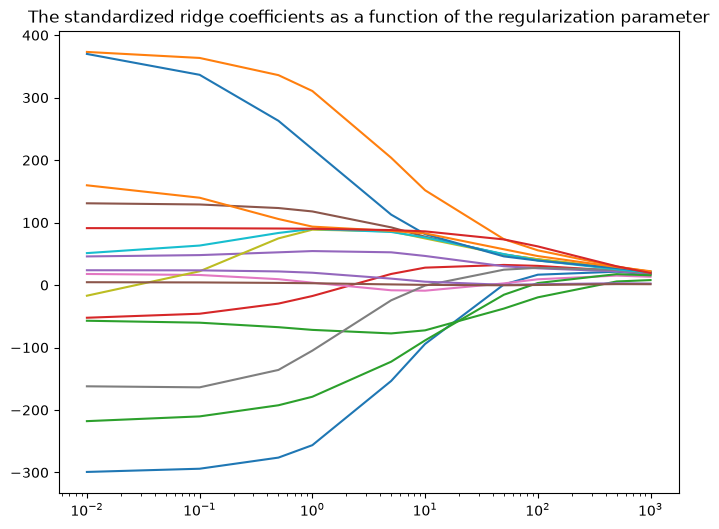

In [8]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.title("The standardized ridge coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

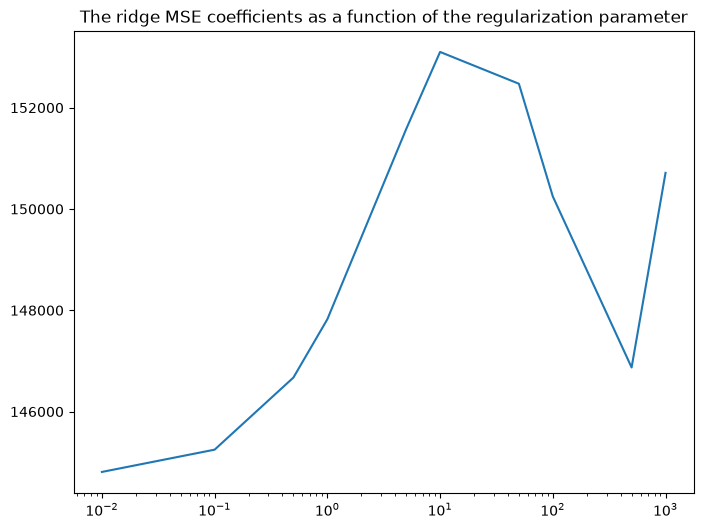

In [9]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs)
ax.set_xscale("log")
plt.title("The ridge MSE coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

In [10]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha = 1) 
lasso.fit(X_train_std, y_train)
print(lasso.coef_, lasso.intercept_)

[-279.549848    338.36783283  -65.7340228   -19.41247991   47.30252392
  120.40616419   -0.           -6.493696      0.           87.63891504
  227.45521361   87.89781153 -188.87973685   90.2513749    17.33970227
    3.65284023] 537.8672131979696


In [11]:
L_coefs = []
L_errs = []

alphas = np.array([0.5, 1, 2.5, 5, 10, 25, 50, 100])

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=2000)
    lasso.fit(X_train_std, y_train)
    L_coefs.append(lasso.coef_)
    L_errs.append(mean_squared_error(y_test, lasso.predict(X_test_std)))

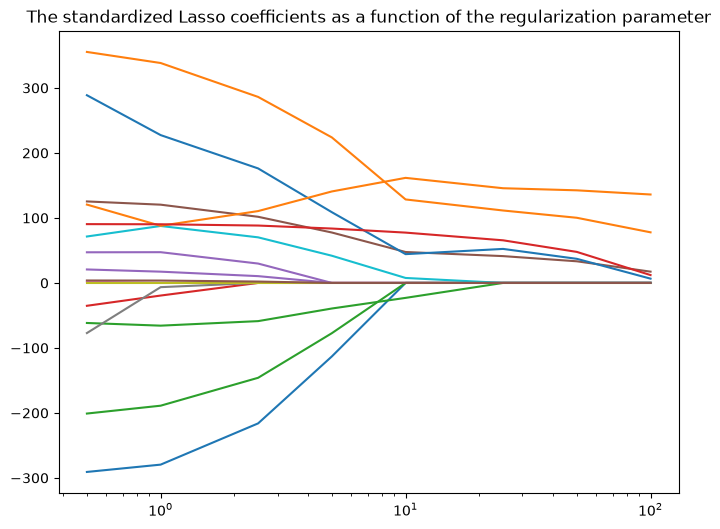

In [12]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_coefs)
ax.set_xscale("log")
plt.title("The standardized Lasso coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

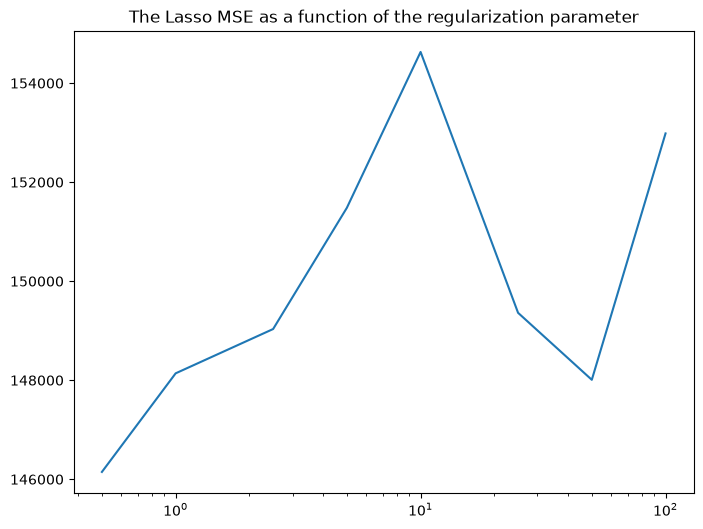

In [13]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_errs)
ax.set_xscale("log")
plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

### With k-fold cross-validation

Ridge regression을 이용하여 앞에서 했던 내용을 반복해 보자.

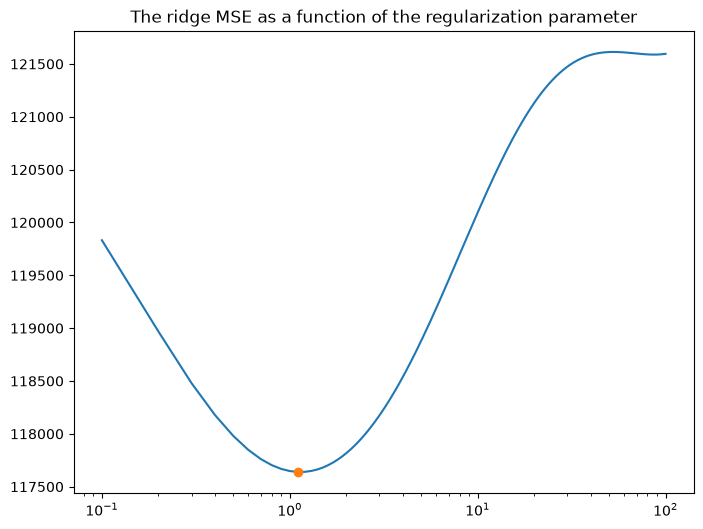

In [14]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
alphas = np.arange(0.1, 100, 0.1)

errs_alpha = [] # alpha별 에러

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Ridge 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=a))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))


plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

plt.title("The ridge MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

Lasso regression을 이용하여 같은 방법을 다시 적용하여 보았다.

In [15]:
from sklearn.model_selection import KFold
alphas = np.arange(1, 10, 0.02)

errs_alpha = [] # alpha별 에러

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Lasso 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=a, max_iter=2000))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))


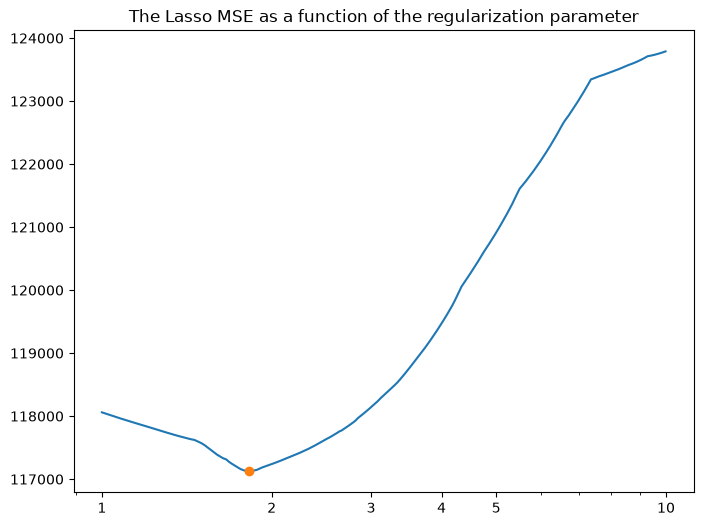

In [16]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')
plt.xticks([1, 2, 3, 4, 5, 10], ['1', '2', '3', '4', '5', '10'])

plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

### sklearn에서의 ElasticNet

[```sklearn.linear_model.ElasticNet```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)

minimize 1 / (2 * n_samples) * ||y - Xw||^2_2 + alpha * l1_ratio * ||w||_1 + 0.5 * alpha * (1 - l1_ratio) * ||w||^2_2

In [17]:
from sklearn.linear_model import ElasticNet
elastic = ElasticNet(alpha = 1, l1_ratio = 0.5)
elastic.fit(X_train_std, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [18]:
print(elastic.coef_, elastic.intercept_)

[ 16.32952267  55.8898862  -19.12549837  30.52982191  26.45660546
  41.14517124   8.93082327  27.61177987  41.62219376  39.34151404
  39.3174975   46.55954713   2.86208379  61.89139469   1.10439806
   0.        ] 537.8672131979696


In [19]:
ridge = Ridge(alpha=1).fit(X_train_std, y_train)
lasso = Lasso(alpha=1).fit(X_train_std, y_train)

pred_lr = lr.predict(X_test_std)
pred_ridge = ridge.predict(X_test_std)
pred_lasso = lasso.predict(X_test_std)
pred_elastic = elastic.predict(X_test_std)

In [20]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_test, pred_lr))
print(mean_squared_error(y_test, pred_ridge))
print(mean_squared_error(y_test, pred_lasso))
print(mean_squared_error(y_test, pred_elastic))

144755.87211655593
147823.2844163086
148139.2446292696
150130.57720163235


## Boston housing 예제

Boston housing dataset

In [21]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True, parser="liac-arff")

X = boston.data.astype(float).values
y = boston.target.astype(float).values

In [22]:
import pandas as pd
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [23]:
pd.DataFrame(y)

,0
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
...,...
501,22.4
502,20.6
503,23.9
504,22.0


In [24]:
from sklearn.model_selection import train_test_split
X_tn, X_te, y_tn, y_te = train_test_split(X, y)

In [25]:
pd.DataFrame(X_tn)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.00245,0.0,8.14,0.0,0.538,6.674,87.3,4.2390,4.0,307.0,21.0,380.23,11.98
1,0.09103,0.0,2.46,0.0,0.488,7.155,92.2,2.7006,3.0,193.0,17.8,394.12,4.82
2,1.19294,0.0,21.89,0.0,0.624,6.326,97.7,2.2710,4.0,437.0,21.2,396.90,12.26
3,0.13642,0.0,10.59,0.0,0.489,5.891,22.3,3.9454,4.0,277.0,18.6,396.90,10.87
4,17.86670,0.0,18.10,0.0,0.671,6.223,100.0,1.3861,24.0,666.0,20.2,393.74,21.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,1.05393,0.0,8.14,0.0,0.538,5.935,29.3,4.4986,4.0,307.0,21.0,386.85,6.58
375,0.17505,0.0,5.96,0.0,0.499,5.966,30.2,3.8473,5.0,279.0,19.2,393.43,10.13
376,0.03427,0.0,5.19,0.0,0.515,5.869,46.3,5.2311,5.0,224.0,20.2,396.90,9.80
377,0.04203,28.0,15.04,0.0,0.464,6.442,53.6,3.6659,4.0,270.0,18.2,395.01,8.16


[`sklearn.preprocessing.StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)와 훈련 데이터를 이용하여 표준화를 하겠다.

In [26]:
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler()
std_scale.fit(X_tn)
X_tn_std = std_scale.transform(X_tn)
X_te_std = std_scale.transform(X_te)

In [27]:
pd.DataFrame(X_tn_std)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.310831,-0.480044,-0.430376,-0.293189,-0.140940,0.556795,0.655245,0.234018,-0.630986,-0.587257,1.195002,0.238808,-0.110050
1,-0.429658,-0.480044,-1.279251,-0.293189,-0.574675,1.227094,0.827739,-0.511569,-0.747245,-1.279205,-0.274428,0.396655,-1.094930
2,-0.285996,-0.480044,1.624558,-0.293189,0.605084,0.071840,1.021354,-0.719775,-0.630986,0.201806,1.286841,0.428247,-0.071535
3,-0.423740,-0.480044,-0.064224,-0.293189,-0.566000,-0.534355,-1.632934,0.091724,-0.630986,-0.769349,0.092930,0.428247,-0.262734
4,1.887847,-0.480044,1.058144,-0.293189,1.012795,-0.071696,1.102320,-1.148643,1.694184,1.591772,0.827644,0.392337,1.237971
...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,-0.304120,-0.480044,-0.430376,-0.293189,-0.140940,-0.473039,-1.386515,0.359833,-0.630986,-0.587257,1.195002,0.314038,-0.852837
375,-0.418704,-0.480044,-0.756176,-0.293189,-0.479253,-0.429839,-1.354833,0.044180,-0.514728,-0.757210,0.368448,0.388814,-0.364523
376,-0.437058,-0.480044,-0.871253,-0.293189,-0.340458,-0.565013,-0.788068,0.714840,-0.514728,-1.091044,0.827644,0.428247,-0.409916
377,-0.436046,0.749554,0.600828,-0.293189,-0.782867,0.233492,-0.531088,-0.043736,-0.630986,-0.811837,-0.090749,0.406769,-0.635503


In [28]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_tn_std, y_tn)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.81, 1.39, 0.25,...,-2.15, 0.76,-4.12]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[48.11,23.54,21.96,..., 8.2 , 7.93, 4.6 ]"


In [29]:
print(lr.coef_, lr.intercept_)

[-0.81003074  1.38514119  0.24560768  0.80777926 -2.15812824  2.31999352
 -0.0246176  -3.65585208  3.10617516 -2.40850649 -2.15109327  0.76499388
 -4.12080834] 22.70422163588394


### sklearn에서의 Ridge, Lasso regression

[```sklearn.linear_model.Ridge```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

minimize ```||y - Xw||^2_2 + alpha * ||w||^2_2```

scikit-learn에서는 정규화 강도를 `alpha`로 지정한다. `alpha`가 클수록 회귀계수가 더 많이 축소된다.

In [30]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1)   
ridge.fit(X_tn_std, y_tn)
print(ridge.coef_, ridge.intercept_)

[-0.79980382  1.36312694  0.21362683  0.81244147 -2.12544462  2.33491533
 -0.02870472 -3.61491131  2.98503948 -2.28938718 -2.1409128   0.76567208
 -4.10012653] 22.70422163588394


다양한 튜닝 파라미터 `alpha`에 대해 진행해 보자.

In [31]:
import numpy as np
from sklearn.metrics import mean_squared_error

alphas = np.array([0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000])

coefs = []
errs = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_tn_std, y_tn)
    coefs.append(ridge.coef_)
    errs.append(mean_squared_error(y_te, ridge.predict(X_te_std)))

In [32]:
pd.DataFrame(coefs)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.809925,1.384915,0.245273,0.807828,-2.157797,2.320148,-0.024660,-3.655439,3.104910,-2.407257,-2.150989,0.765001,-4.120598
1,-0.808974,1.382885,0.242274,0.808269,-2.154823,2.321530,-0.025038,-3.651721,3.093575,-2.396067,-2.150057,0.765063,-4.118709
2,-0.804823,1.373985,0.229247,0.810174,-2.141683,2.327577,-0.026692,-3.635279,3.044279,-2.347510,-2.145953,0.765338,-4.110381
3,-0.799804,1.363127,0.213627,0.812441,-2.125445,2.334915,-0.028705,-3.614911,2.985039,-2.289387,-2.140913,0.765672,-4.100127
4,-0.765275,1.285418,0.110238,0.826894,-2.002797,2.386102,-0.042951,-3.459359,2.588691,-1.907885,-2.103700,0.767989,-4.023349
5,-0.732409,1.205823,0.018561,0.838636,-1.866431,2.435655,-0.057402,-3.282621,2.228808,-1.575343,-2.063212,0.770007,-3.937383
6,-0.620061,0.871468,-0.246237,0.856475,-1.204957,2.579315,-0.121669,-2.346316,1.079966,-0.674837,-1.848187,0.762495,-3.438040
7,-0.578250,0.709295,-0.327717,0.837630,-0.850245,2.542544,-0.160311,-1.743694,0.632721,-0.450822,-1.682963,0.729996,-3.030419
8,-0.489669,0.465981,-0.404826,0.608349,-0.392745,1.763114,-0.249606,-0.496354,-0.047218,-0.354579,-1.103337,0.519472,-1.756460
9,-0.417522,0.383910,-0.381437,0.432502,-0.330754,1.247824,-0.260526,-0.176432,-0.170831,-0.344958,-0.807642,0.399724,-1.227922


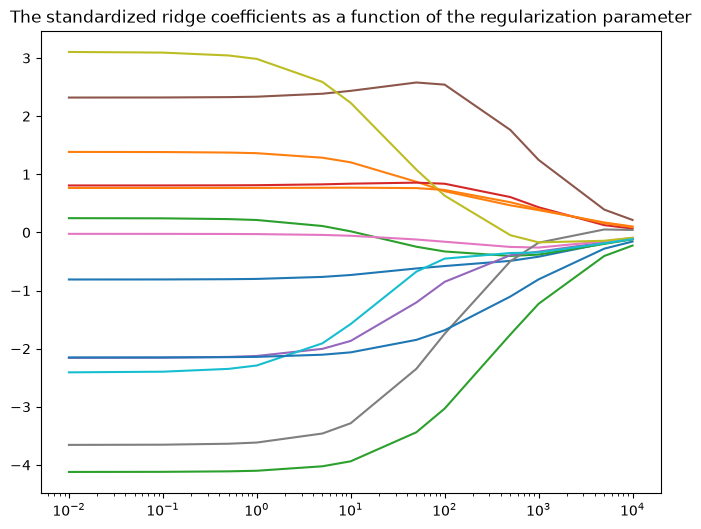

In [33]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.title("The standardized ridge coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

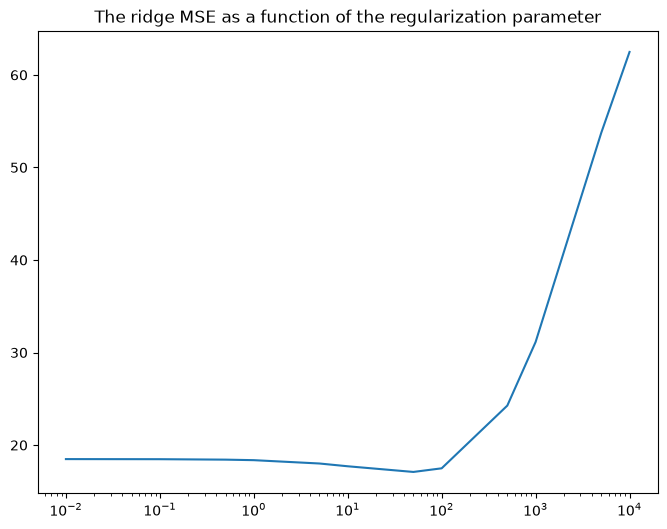

In [34]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs)
ax.set_xscale("log")
plt.title("The ridge MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

### [```sklearn.linear_model.Lasso```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)를 이용한 예제

다음을 최소화한다.

minimize 1 / (2 * n_samples)) * ||y - Xw||^2_2 + alpha * ||w||_1

In [35]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha = 0.1) 
lasso.fit(X_tn_std, y_tn)
print(lasso.coef_, lasso.intercept_)

[-0.49233059  1.03290557 -0.          0.77828131 -1.71299234  2.44256992
 -0.         -3.0228516   1.37775962 -0.87957924 -2.01530764  0.67010001
 -4.12888413] 22.70422163588394


In [36]:
L_coefs = []
L_errs = []

alphas = np.arange(0.1, 10, 0.1)

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_tn_std, y_tn)
    L_coefs.append(lasso.coef_)
    L_errs.append(mean_squared_error(y_te, lasso.predict(X_te_std)))

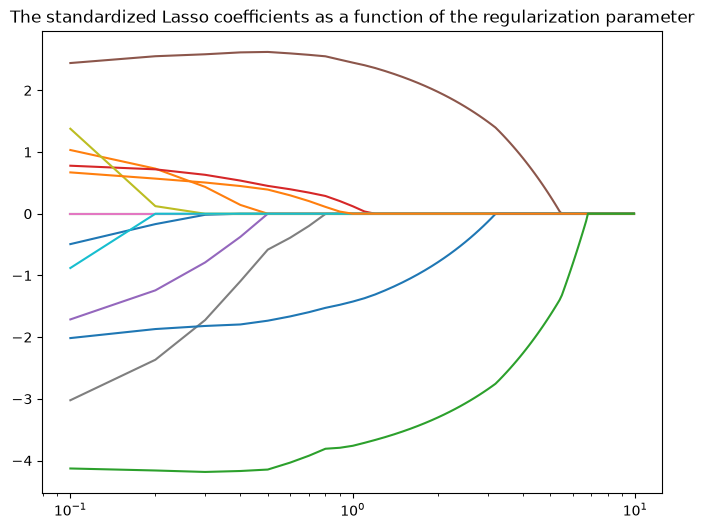

In [37]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_coefs)
ax.set_xscale("log")
plt.title("The standardized Lasso coefficients as a function of the regularization parameter")
plt.axis("tight")
plt.show()

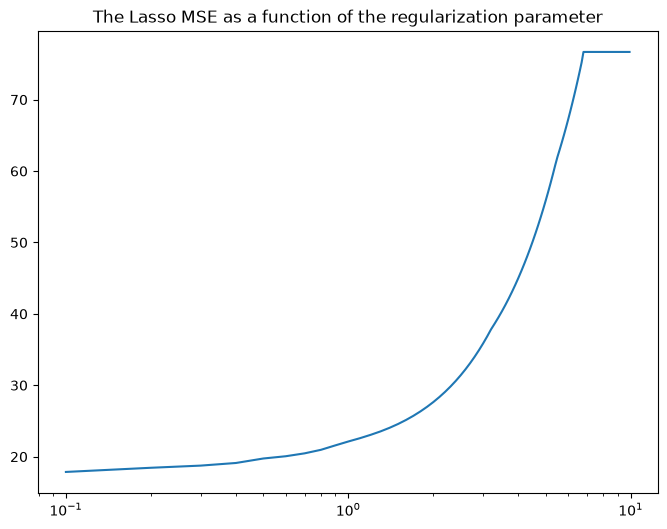

In [38]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, L_errs)
ax.set_xscale("log")
plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

### with K-fold cross validation

앞 단원에서 공부했던 k-fold cross validation 방법을 다시 적용하여 보자.

In [39]:
from sklearn.model_selection import KFold
import numpy as np
from sklearn.preprocessing import StandardScaler

alphas = np.arange(0.01, 10, 0.01)

errs_alpha = [] # alpha별 에러

for a in alphas:
    
    kfold_errs = []  # 각 폴드 별 에러
    
    kf = KFold(n_splits = 5, shuffle=True, random_state=1)
    
    for train_index, test_index in kf.split(X):
    
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        std_scale = StandardScaler()
        std_scale.fit(X_train)
        
        X_train_std = std_scale.transform(X_train)
        X_test_std = std_scale.transform(X_test)
        
        ridge = Ridge(alpha = a)
        ridge.fit(X_train_std, y_train)
        
        kfold_errs.append(mean_squared_error(y_test, ridge.predict(X_test_std)))
        
    errs_alpha.append(np.mean(kfold_errs))

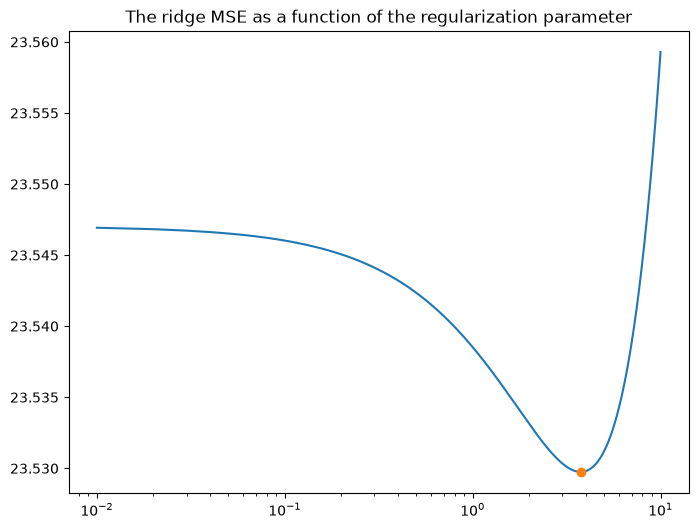

In [40]:
plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

plt.title("The ridge MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

혹은 더 간단하게 `cross_val_score`를 이용한 버전을 살펴보자.

* 아래 코드에서  `'neg_mean_squared_error'`는 MSE의 음수값을 나타내므로, mse 평균을 구할 때는 다시 마이너스를 취한다.

* `cross_val_score` 함수의 기본 동작은 높은 값일수록 좋은 성능으로 간주하도록 되어 있어, 음의 평균 제곱 오차를 사용하도록 구현되어 있다.

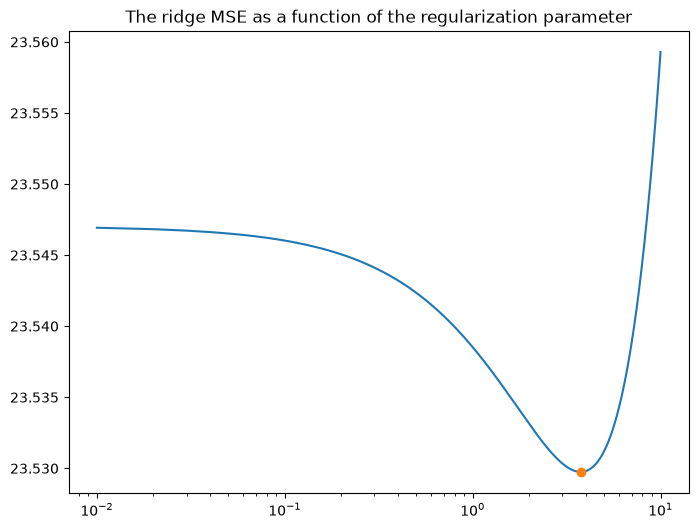

In [41]:
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# alpha 값들
alphas = np.arange(0.01, 10, 0.01)
errs_alpha = []
cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Ridge 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=a))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))


plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

plt.title("The ridge MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

Lasso에 대해서도 비슷하게 해 보자.

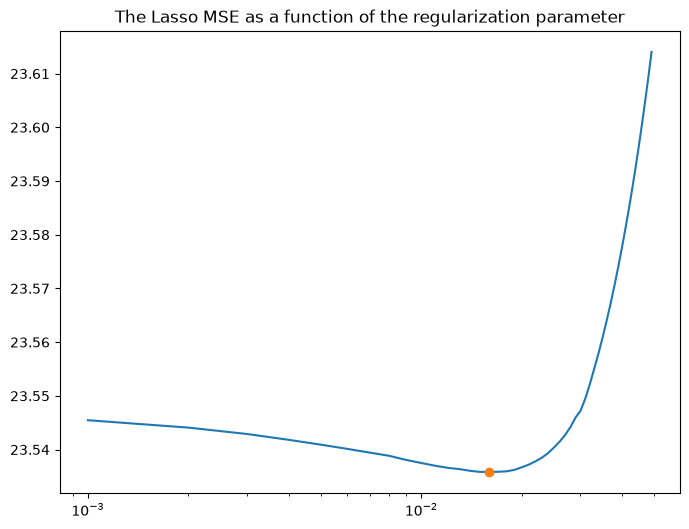

In [42]:

alphas = np.arange(0.001, 0.05, 0.001)
errs_alpha = [] # alpha별 에러

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for a in alphas:
    
    # 파이프라인: 표준화 + Lasso 회귀
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=a))
    ])
    
    neg_mse_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_squared_error')
    
    # 음수를 취하여 평균 MSE 저장
    errs_alpha.append(np.mean(-neg_mse_scores))


plt.figure(figsize=(8, 6))

ax = plt.gca()
ax.plot(alphas, errs_alpha)
ax.set_xscale("log")
ax.plot(alphas[np.argmin(errs_alpha)], np.min(errs_alpha), marker = 'o')

plt.title("The Lasso MSE as a function of the regularization parameter")
plt.axis("tight")
plt.show()

### sklearn에서의 ElasticNet

[```sklearn.linear_model.ElasticNet```](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)

minimize 1 / (2 * n_samples) * ||y - Xw||^2_2 + alpha * l1_ratio * ||w||_1 + 0.5 * alpha * (1 - l1_ratio) * ||w||^2_2

In [43]:
from sklearn.linear_model import ElasticNet
elastic = ElasticNet(alpha = 0.1, l1_ratio = 0.5)
elastic.fit(X_tn_std, y_tn)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [44]:
print(elastic.coef_, elastic.intercept_)

[-0.5712716   0.97729824 -0.07074007  0.81554053 -1.52252354  2.52585633
 -0.         -2.71781435  1.31613651 -0.84098609 -1.96050247  0.72633219
 -3.83067665] 22.70422163588394


In [45]:
ridge = Ridge(alpha=1).fit(X_tn_std, y_tn)
lasso = Lasso(alpha=0.1).fit(X_tn_std, y_tn)

pred_lr = lr.predict(X_te_std)
pred_ridge = ridge.predict(X_te_std)
pred_lasso = lasso.predict(X_te_std)
pred_elastic = elastic.predict(X_te_std)


In [46]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_te, pred_lr))
print(mean_squared_error(y_te, pred_ridge))
print(mean_squared_error(y_te, pred_lasso))
print(mean_squared_error(y_te, pred_elastic))

18.4884152224296
18.371539825514848
17.860484814793583
17.370866467963438
